In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("Maintanence_dataset.csv")
df.columns = df.columns.str.strip()  


In [4]:
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
TIME                 0
FM1_manual         720
PE1_manual         720
PE2_manual         720
PE3_manual         720
PE4_manual         720
TP1_manual         720
EPOCH_manual       720
FM1_iiot        110641
PE1_iiot        110641
PE2_iiot        110641
PE3_iiot        110641
PE4_iiot        110641
TP1_iiot        110641
TP2             110641
EPOCH_iiot      110641
dtype: int64


In [5]:
sensor_cols = ['TP1_iiot', 'PE1_iiot', 'FM1_iiot']
df = df.dropna(subset=sensor_cols)


In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # or median
df[sensor_cols] = imputer.fit_transform(df[sensor_cols])


In [7]:
df['tp_pe_ratio'] = df['TP1_iiot'] / (df['PE1_iiot'] + 1e-6)  # ratio
df['tp_plus_pe'] = df['TP1_iiot'] + df['PE1_iiot']


In [8]:
df['sensor_mean'] = df[sensor_cols].mean(axis=1)
df['sensor_std'] = df[sensor_cols].std(axis=1)


In [9]:
from scipy.stats import zscore

# Calculate Z-scores for selected features
z_scores = np.abs(zscore(df[sensor_cols]))
df = df[(z_scores < 3).all(axis=1)]  # keep rows where all z-scores < 3

print("Shape after outlier removal:", df.shape)


Shape after outlier removal: (696, 20)


In [16]:
# Recreate failure column if not already done
df['failure'] = ((df['TP1_iiot'] > 0.2) & (df['PE1_iiot'] > 0.2)).astype(int)

# Confirm it's added
print("🔹 Target 'failure' distribution:")
print(df['failure'].value_counts())


🔹 Target 'failure' distribution:
failure
1    529
0    167
Name: count, dtype: int64


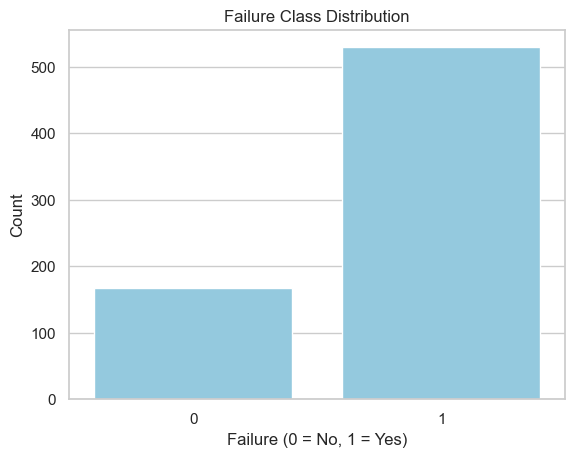

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style='whitegrid')

# Count of failure without 'hue' and without warning
ax = sns.countplot(x='failure', data=df, color='skyblue')  # Use `color` instead of `palette`
plt.title("Failure Class Distribution")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


<Axes: xlabel='failure', ylabel='count'>

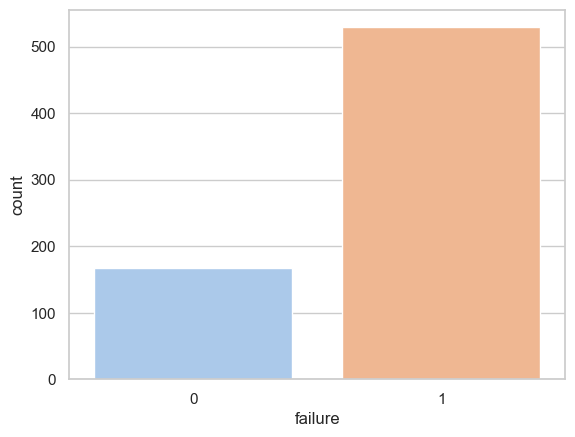

In [19]:
sns.countplot(hue='failure', x='failure', data=df, palette='pastel', legend=False)


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


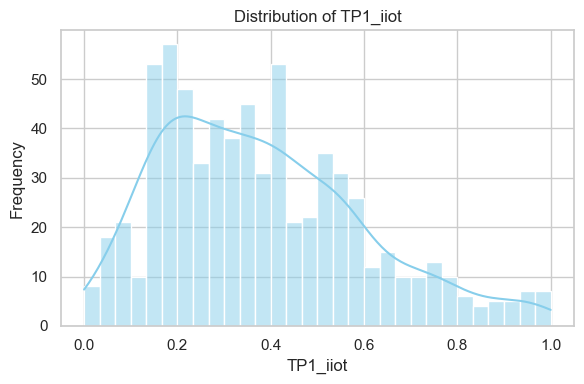

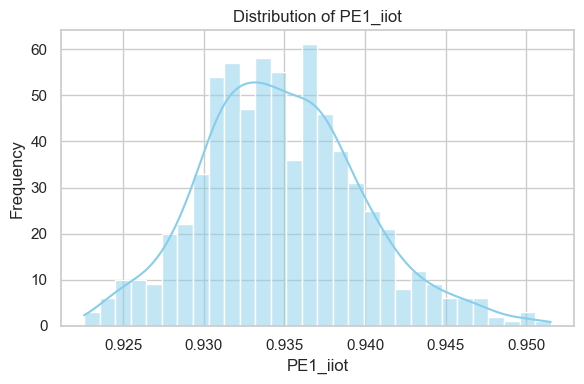

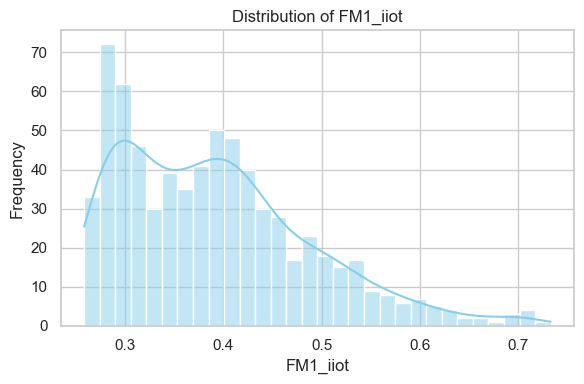

In [11]:
sensor_cols = ['TP1_iiot', 'PE1_iiot', 'FM1_iiot']

for col in sensor_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


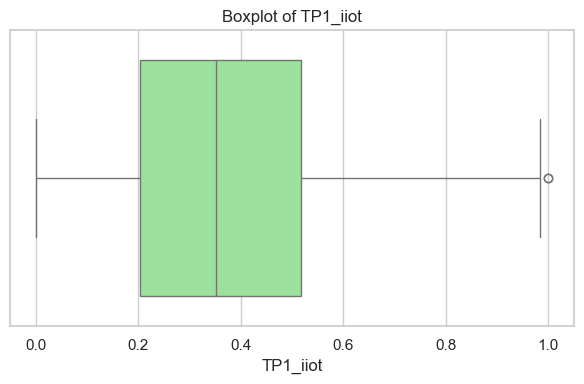

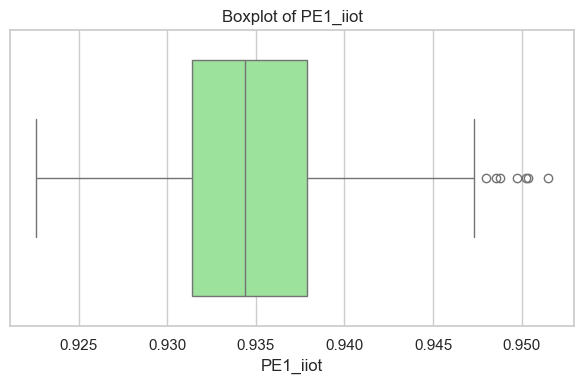

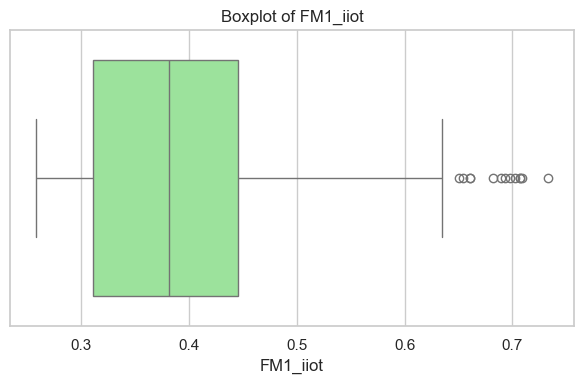

In [12]:
for col in sensor_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


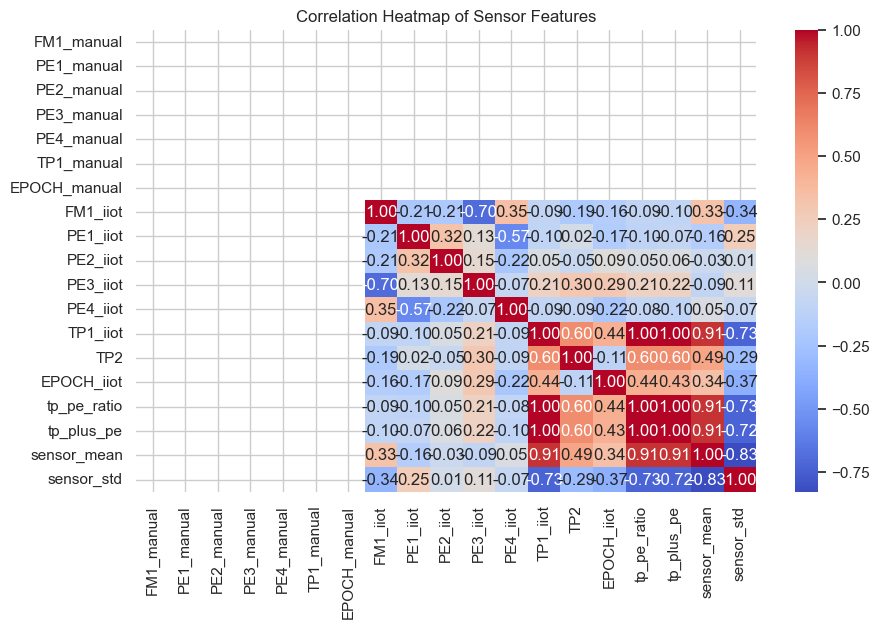

In [13]:
# Only numeric features
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Sensor Features")
plt.show()


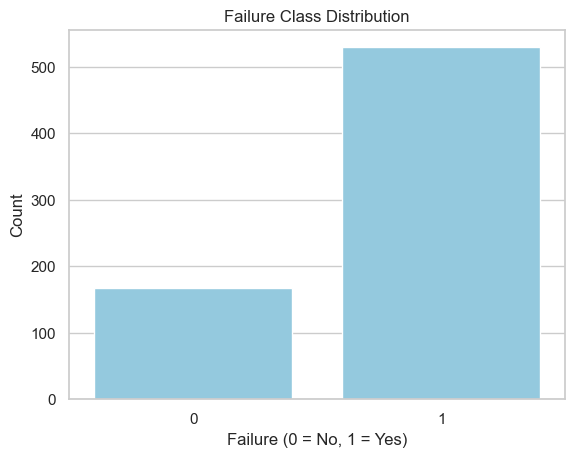

In [22]:
sns.countplot(x='failure', data=df, color='skyblue')  # no palette, no hue
plt.title("Failure Class Distribution")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [24]:
# Use base sensor features
features = ['TP1_iiot', 'PE1_iiot', 'FM1_iiot']
X = df[features]
y = df['failure']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("🔹 Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr, zero_division=0))


🔹 Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.70      0.82        33
           1       0.91      1.00      0.96       107

    accuracy                           0.93       140
   macro avg       0.96      0.85      0.89       140
weighted avg       0.93      0.93      0.92       140



In [27]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("🔹 Random Forest Results:")
print(classification_report(y_test, y_pred_rf, zero_division=0))


🔹 Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00       107

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



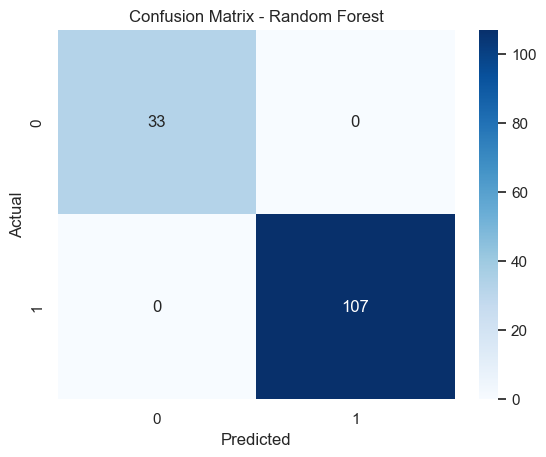

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [29]:
from sklearn.model_selection import cross_val_score, GridSearchCV


In [30]:
lr_cv = LogisticRegression()
cv_scores_lr = cross_val_score(lr_cv, X, y, cv=5, scoring='f1')

print("Logistic Regression - 5 Fold F1 Scores:", cv_scores_lr)
print("Average F1 Score:", cv_scores_lr.mean())


Logistic Regression - 5 Fold F1 Scores: [0.93636364 0.90517241 0.90598291 0.99065421 0.97695853]
Average F1 Score: 0.9430263374185488


In [31]:
rf_cv = RandomForestClassifier()
cv_scores_rf = cross_val_score(rf_cv, X, y, cv=5, scoring='f1')

print("Random Forest - 5 Fold F1 Scores:", cv_scores_rf)
print("Average F1 Score:", cv_scores_rf.mean())


Random Forest - 5 Fold F1 Scores: [1.         1.         1.         1.         0.99526066]
Average F1 Score: 0.9990521327014218


In [32]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X, y)

print("Best Logistic Regression Parameters:", grid_lr.best_params_)
print("Best F1 Score:", grid_lr.best_score_)


Best Logistic Regression Parameters: {'C': 10, 'solver': 'liblinear'}
Best F1 Score: 0.9810604963351901


In [34]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X, y)

print("Best Random Forest Parameters:", grid_rf.best_params_)
print("Best F1 Score:", grid_rf.best_score_)


Best Random Forest Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best F1 Score: 0.9990521327014218


In [35]:
features = ['TP1_iiot', 'PE1_iiot', 'FM1_iiot']
X_unsup = df[features]


In [38]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_unsup)

# View cluster distribution
print(df['cluster'].value_counts())
import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")



cluster
0    461
1    235
Name: count, dtype: int64


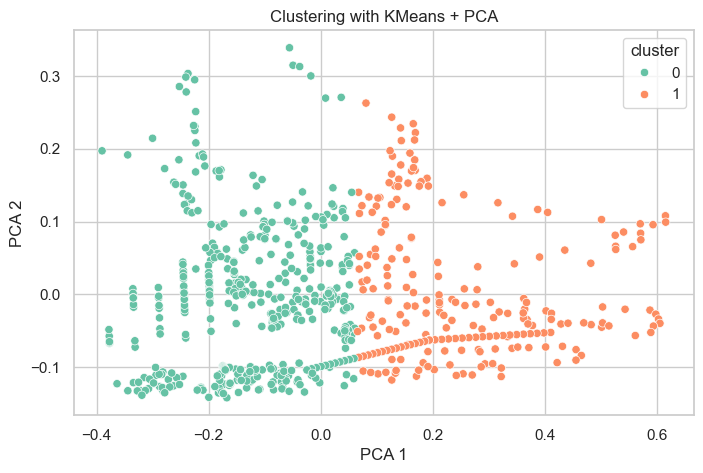

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce to 2D
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_unsup)

# Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=df['cluster'], palette='Set2')
plt.title("Clustering with KMeans + PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


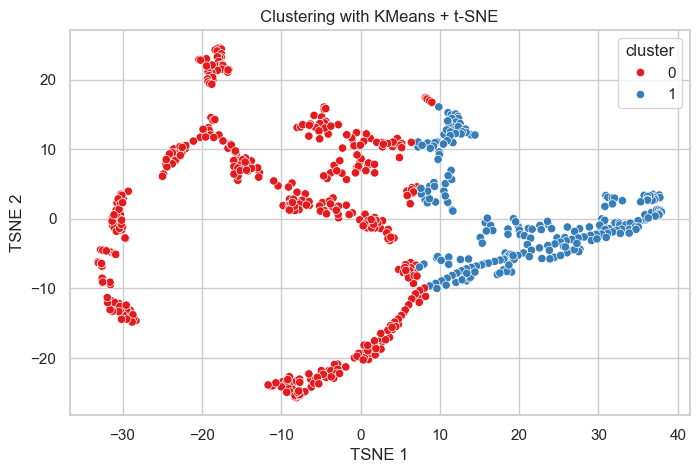

In [40]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(X_unsup)

# Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=df['cluster'], palette='Set1')
plt.title("Clustering with KMeans + t-SNE")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.show()


In [42]:
pd.crosstab(df['cluster'], df['failure'], margins=True)


failure,0,1,All
cluster,,,
0,167,294,461
1,0,235,235
All,167,529,696


In [43]:
import joblib

# Save trained random forest model
joblib.dump(rf, 'predictive_model.pkl')


['predictive_model.pkl']

In [1]:
import streamlit as st
import joblib
import numpy as np
import pandas as pd

# Load the saved model
model = joblib.load('predictive_model.pkl')

# Page Title
st.title("🛠️ Predictive Maintenance Dashboard")

st.markdown("Enter standardized sensor readings to predict equipment failure.")

# User input sliders
tp1 = st.slider("Temperature (TP1_iiot)", -3.0, 3.0, 0.0)
pe1 = st.slider("Pressure (PE1_iiot)", -3.0, 3.0, 0.0)
fm1 = st.slider("Flow/Vibration (FM1_iiot)", -3.0, 3.0, 0.0)

# Predict button
if st.button("Predict Failure"):
    input_data = np.array([[tp1, pe1, fm1]])
    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("⚠️ Machine is likely to FAIL soon!")
    else:
        st.success("✅ Machine is functioning normally.")


2025-07-06 16:37:19.149 
  command:

    streamlit run C:\Users\91944\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
